In [1]:
import geopandas as gpd
from dem_stitcher.geojson_io import read_geojson_gzip
from rasterio.crs import CRS
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
from shapely import STRtree
from tqdm import tqdm
import numpy as np

# Natural Earth

In [2]:
# land_url = 'https://raw.githubusercontent.com/martynafford/natural-earth-geojson/refs/heads/master/10m/physical/ne_10m_land.json'
# df_ne_land = gpd.read_file(land_url)

In [3]:
# minor_islands_url = 'https://raw.githubusercontent.com/martynafford/natural-earth-geojson/refs/heads/master/10m/physical/ne_10m_minor_islands.json'
# df_ne_mi = gpd.read_file(minor_islands_url)

In [4]:
# df_ne_all_land = pd.concat([df_ne_mi, df_ne_land])
# land_geo = df_ne_all_land.geometry.unary_union

# MGRS

In [5]:
df_mgrs = gpd.read_parquet('../N_hls_tiles/mgrs.parquet')
df_mgrs = df_mgrs.rename(columns={'tile_id': 'mgrs_tile_id'})
print('Total MGRS tiles: ', df_mgrs.shape[0])
df_mgrs.head()

Total MGRS tiles:  56686


,mgrs_tile_id,epsg,utm_wkt,geometry
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."
1,01CDH,32701,"MULTIPOLYGON(((399960 800020,399960 690220,509...","MULTIPOLYGON (((-176.29744 -82.85185, -176.185..."
2,01CDJ,32701,"MULTIPOLYGON(((399960 900040,399960 790240,509...","MULTIPOLYGON (((-176.37525 -81.95591, -176.288..."
3,01CDK,32701,"MULTIPOLYGON(((399960 1000000,399960 890200,50...","MULTIPOLYGON (((-176.43739 -81.06046, -176.368..."
4,01CDL,32701,"MULTIPOLYGON(((399960 1100020,399960 990220,50...","MULTIPOLYGON (((-176.48820 -80.16441, -176.431..."


In [6]:
# %%time
# tree = STRtree(df_mgrs.geometry)
# idxs_land = tree.query(land_geo, predicate="intersects")

In [7]:
with open('dist_hls_tiles.txt') as f:
    hls_tiles = f.readlines()
hls_tiles = list(map(lambda tile: tile.strip(), hls_tiles))
hls_tiles[:3]

['01RGJ', '01RFL', '01REL']

In [8]:
idxs_dist = df_mgrs.mgrs_tile_id.isin(hls_tiles)
idxs_dist

0        False
1        False
2        False
3        False
4        False
         ...  
56681    False
56682    False
56683    False
56684    False
56685    False
Name: mgrs_tile_id, Length: 56686, dtype: bool

In [9]:
df_mgrs_land = df_mgrs[idxs_dist].reset_index(drop=True)
n = df_mgrs_land.shape[0]
f'Total MGRS tiles over land: {n}'

'Total MGRS tiles over land: 19043'

<Axes: >

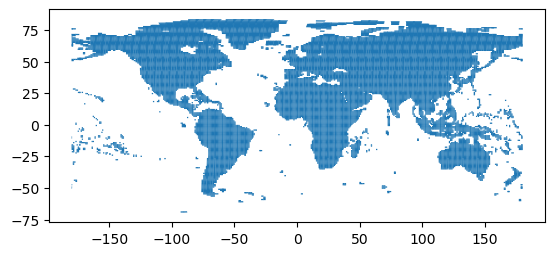

In [10]:
df_mgrs_land.plot()

# JPL Bursts

In [11]:
df_burst = read_geojson_gzip('../A_download_burst_data/opera_burst_ids.geojson.zip')
df_burst.head()

,geometry,burst_id_jpl,is_land,is_north_america,orbit_pass
0,"POLYGON ((2.53190 4.75701, 3.29631 4.91201, 3....",t001_000025_iw1,1,False,ASCENDING
1,"POLYGON ((3.25912 4.97460, 4.06055 5.13657, 4....",t001_000025_iw2,1,False,ASCENDING
2,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4....",t001_000025_iw3,1,False,ASCENDING
3,"POLYGON ((2.49611 4.92361, 3.26087 5.07851, 3....",t001_000026_iw1,1,False,ASCENDING
4,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3....",t001_000026_iw2,1,False,ASCENDING


In [12]:
burst_geos = df_burst.geometry.tolist()
burst_id = df_burst.burst_id_jpl.str.upper().str.replace('_', '-').tolist()
track_number = df_burst.burst_id_jpl.map(lambda burst_id: int(burst_id.split('_')[0][1:]))
orbit_pass = df_burst.orbit_pass.tolist()

In [13]:
df_burst_final = gpd.GeoDataFrame({'jpl_burst_id': burst_id,
                                   'orbit_pass': orbit_pass,
                                   'track_number': track_number,
                                   #'is_land': df_burst.is_land.tolist()
                                  },
                                   geometry=burst_geos,
                                   crs=CRS.from_epsg(4326))
df_burst_final.head()

,jpl_burst_id,orbit_pass,track_number,geometry
0,T001-000025-IW1,ASCENDING,1,"POLYGON ((2.53190 4.75701, 3.29631 4.91201, 3...."
1,T001-000025-IW2,ASCENDING,1,"POLYGON ((3.25912 4.97460, 4.06055 5.13657, 4...."
2,T001-000025-IW3,ASCENDING,1,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4...."
3,T001-000026-IW1,ASCENDING,1,"POLYGON ((2.49611 4.92361, 3.26087 5.07851, 3...."
4,T001-000026-IW2,ASCENDING,1,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3...."


# Serialize MGRS and Burst Data

In [14]:
df_burst_final.to_parquet('jpl_burst.parquet', compression='zstd')
df_mgrs_land.to_parquet('mgrs.parquet', compression='zstd')

# Multipolygons along Antimeridian

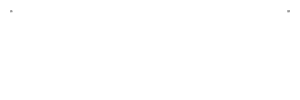

In [15]:
multi_geo = df_burst_final[df_burst_final.jpl_burst_id == 'T008-015335-IW1'].geometry.values[0]
multi_geo

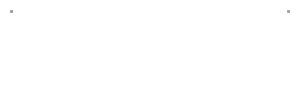

In [16]:
anti_meridian_tile_id = '01VCK'
df_mgrs[df_mgrs.mgrs_tile_id == anti_meridian_tile_id].geometry.values[0]

# Spatial Join

In [17]:
%%time

df_mgrs_burst = gpd.sjoin(df_mgrs, df_burst_final, how='inner', predicate='intersects')
df_mgrs_burst = df_mgrs_burst.drop(columns='index_right').reset_index(drop=True)
df_mgrs_burst.head()

CPU times: user 2.19 s, sys: 153 ms, total: 2.34 s
Wall time: 2.34 s


,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121820-IW1,DESCENDING,57
1,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121819-IW1,DESCENDING,57
2,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121818-IW1,DESCENDING,57
3,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121817-IW1,DESCENDING,57
4,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T130-278615-IW1,DESCENDING,130


# Visualization/Explanation

## Looking at Burst Coverage over MGRS tiles - Known Edge Cases

### Lots of Tracks

In [18]:
tile_id_large_num_tracks = '04CDU' #df_mgrs_burst.mgrs_tile_id.sample(n=1, random_state=3).values[0]

tile_id_large_num_tracks

'04CDU'

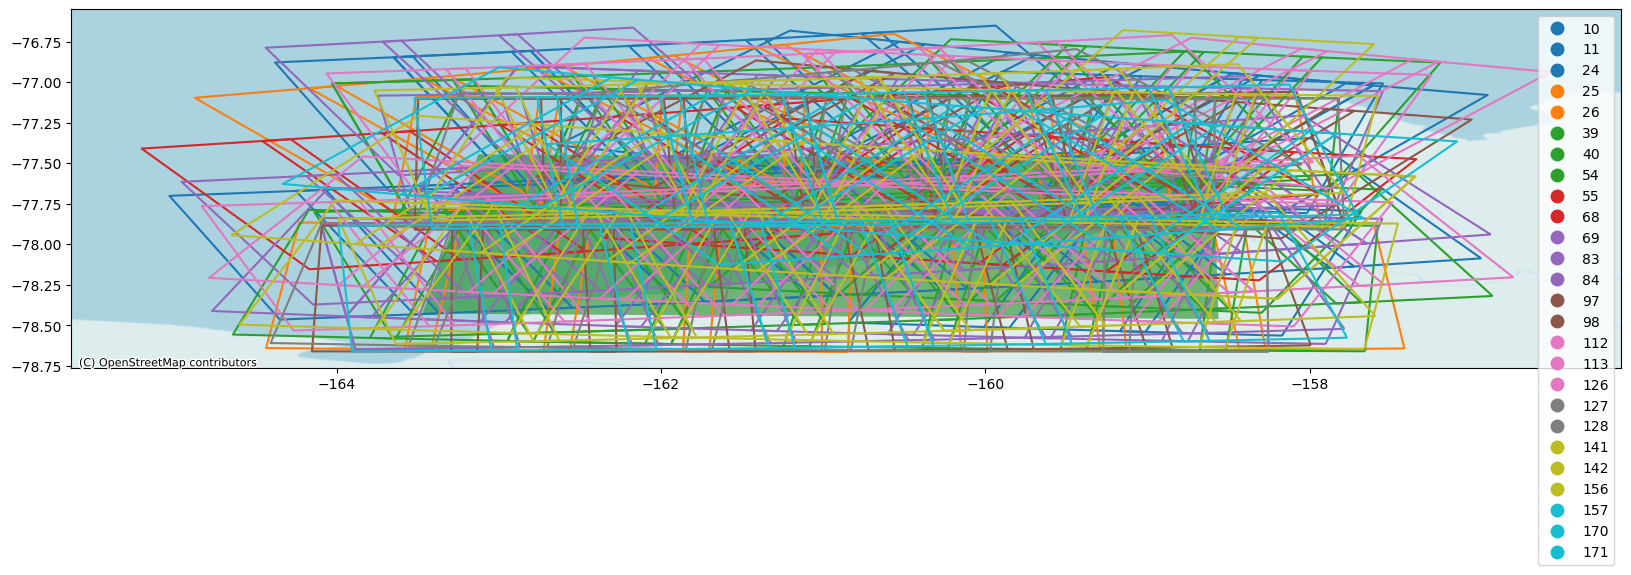

In [19]:
df_mrgs_burst_subset = df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == tile_id_large_num_tracks].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == tile_id_large_num_tracks].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

Remember in these high lattidude areas, these all represent different data takes!

<Axes: >

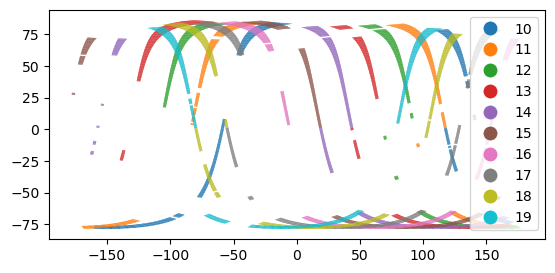

In [20]:
df_burst_final[df_burst_final['track_number'].isin(list(range(10, 20)))].plot(column='track_number', categorical=True, legend=True)

## With a Small Overlapping Burst

In [21]:
mgrs_id_with_small_burst_overlapping = '31QGE'

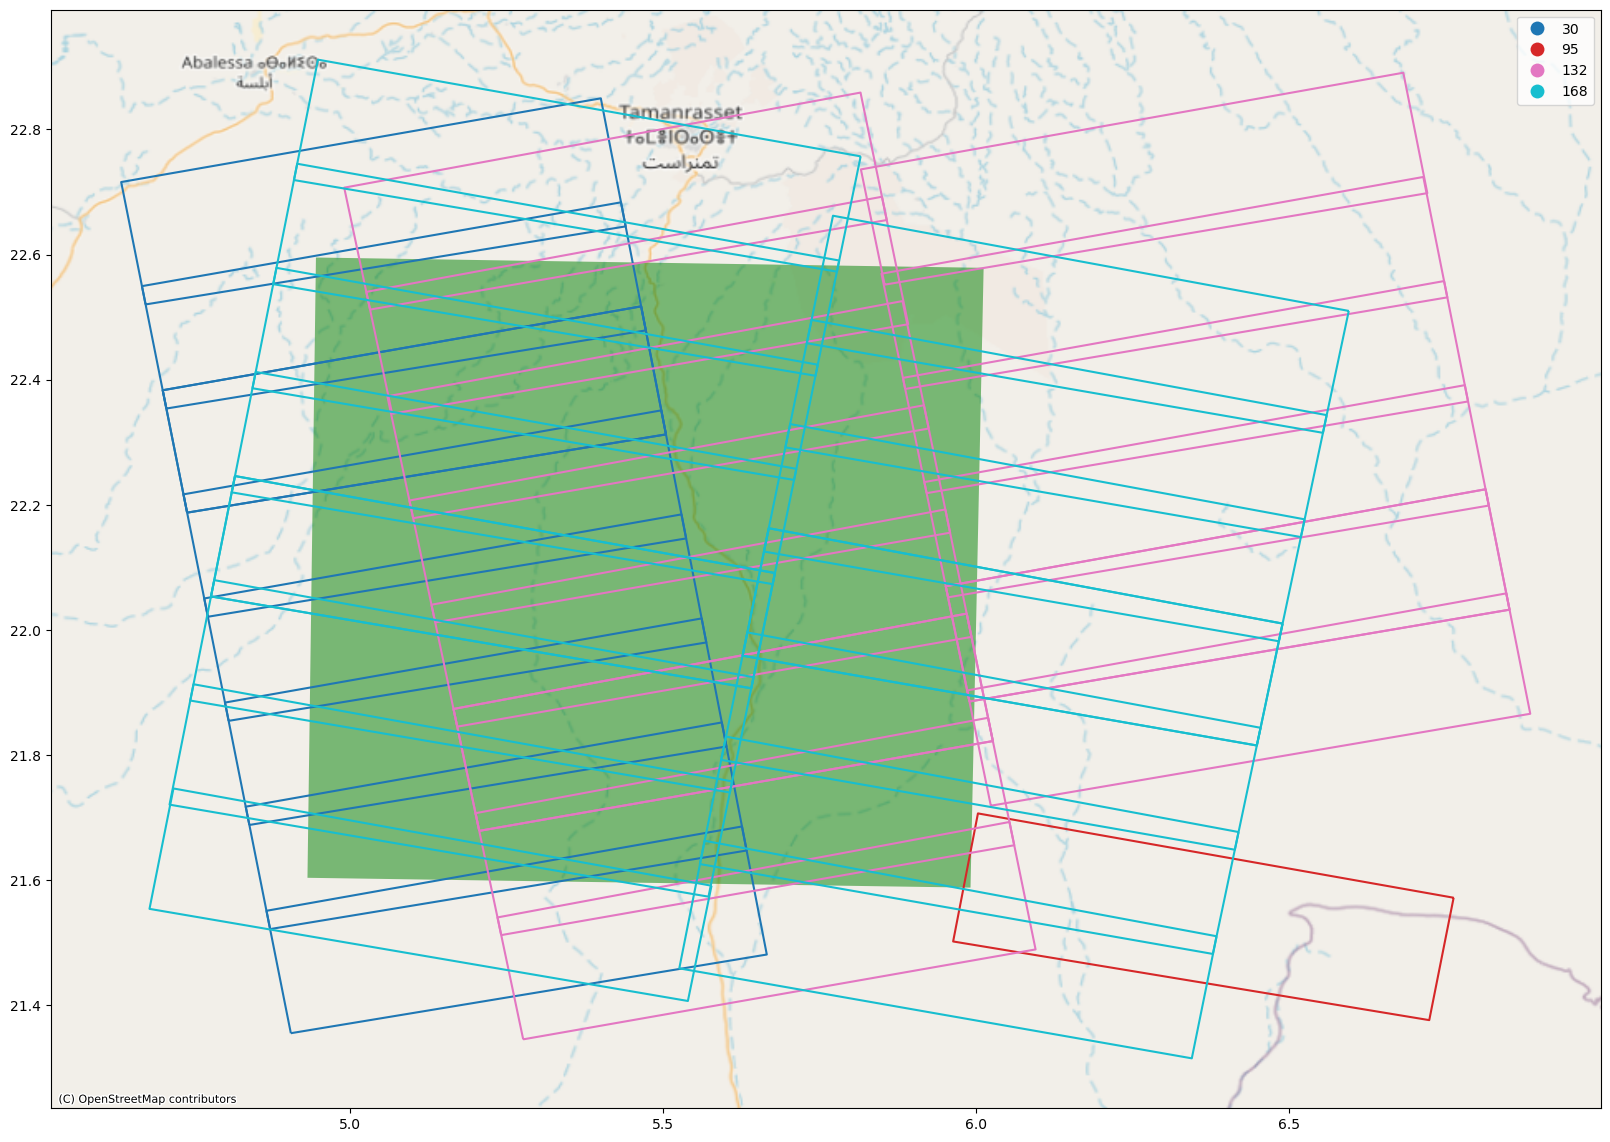

In [22]:
df_mrgs_burst_subset = df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == mgrs_id_with_small_burst_overlapping].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == mgrs_id_with_small_burst_overlapping].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

### Random

In [23]:
random_mgrs_tile_id = df_mgrs_burst.mgrs_tile_id.sample(n=1, random_state=40).values[0]
random_mgrs_tile_id

'17WMT'

In [24]:
df_mrgs_burst_subset = df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
df_mrgs_burst_subset.head()

,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,17WMT,32617,"MULTIPOLYGON(((399960 7800000,399960 7690200,5...","POLYGON ((-83.65806 70.28642, -83.53691 69.302...",T143-305665-IW1,DESCENDING,143
1,17WMT,32617,"MULTIPOLYGON(((399960 7800000,399960 7690200,5...","POLYGON ((-83.65806 70.28642, -83.53691 69.302...",T041-086574-IW1,DESCENDING,41
2,17WMT,32617,"MULTIPOLYGON(((399960 7800000,399960 7690200,5...","POLYGON ((-83.65806 70.28642, -83.53691 69.302...",T106-225943-IW3,ASCENDING,106
3,17WMT,32617,"MULTIPOLYGON(((399960 7800000,399960 7690200,5...","POLYGON ((-83.65806 70.28642, -83.53691 69.302...",T041-086576-IW1,DESCENDING,41
4,17WMT,32617,"MULTIPOLYGON(((399960 7800000,399960 7690200,5...","POLYGON ((-83.65806 70.28642, -83.53691 69.302...",T143-305665-IW1,DESCENDING,143


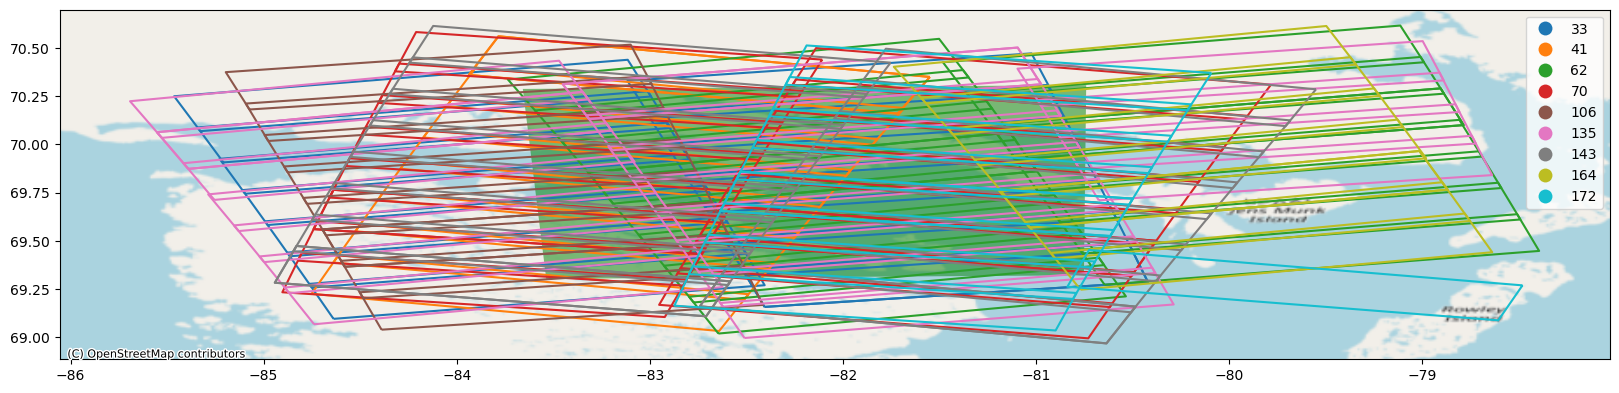

In [25]:
df_mrgs_burst_subset = df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

### Near Antimeridian

In [26]:
anti_meridian_tile_id = '01VCK'

<Axes: >

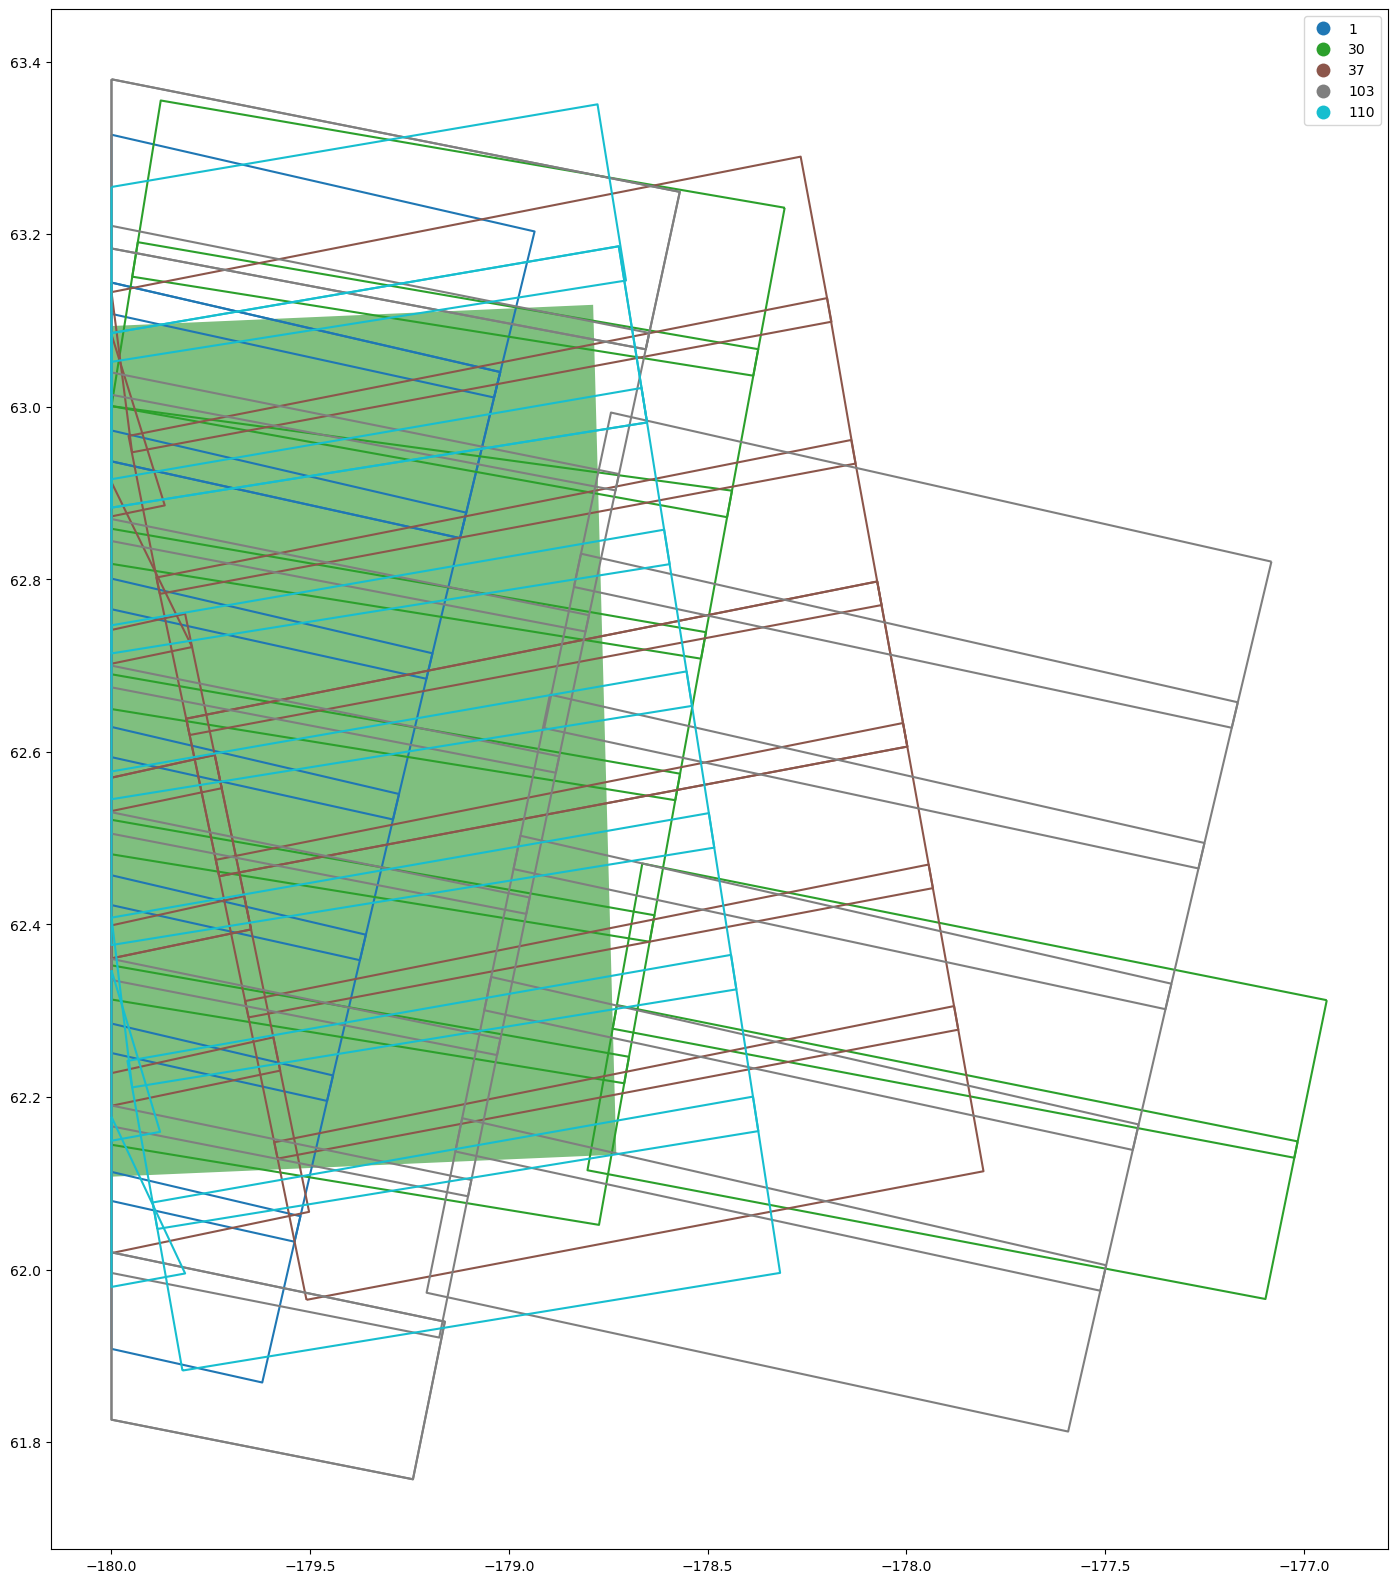

In [27]:
df_mrgs_burst_subset = df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == anti_meridian_tile_id].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == anti_meridian_tile_id].explode(ignore_index=True).cx[:0, :].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].explode(ignore_index=True).cx[:0, :].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
# ctx.add_basemap(ax,
#                crs=df_mgrs_plot.crs.to_string(),
#                source=ctx.providers.OpenStreetMap.Mapnik
#               )

### Near Equator

In [28]:
mgrs_tile_id_near_eq = '22NFF'

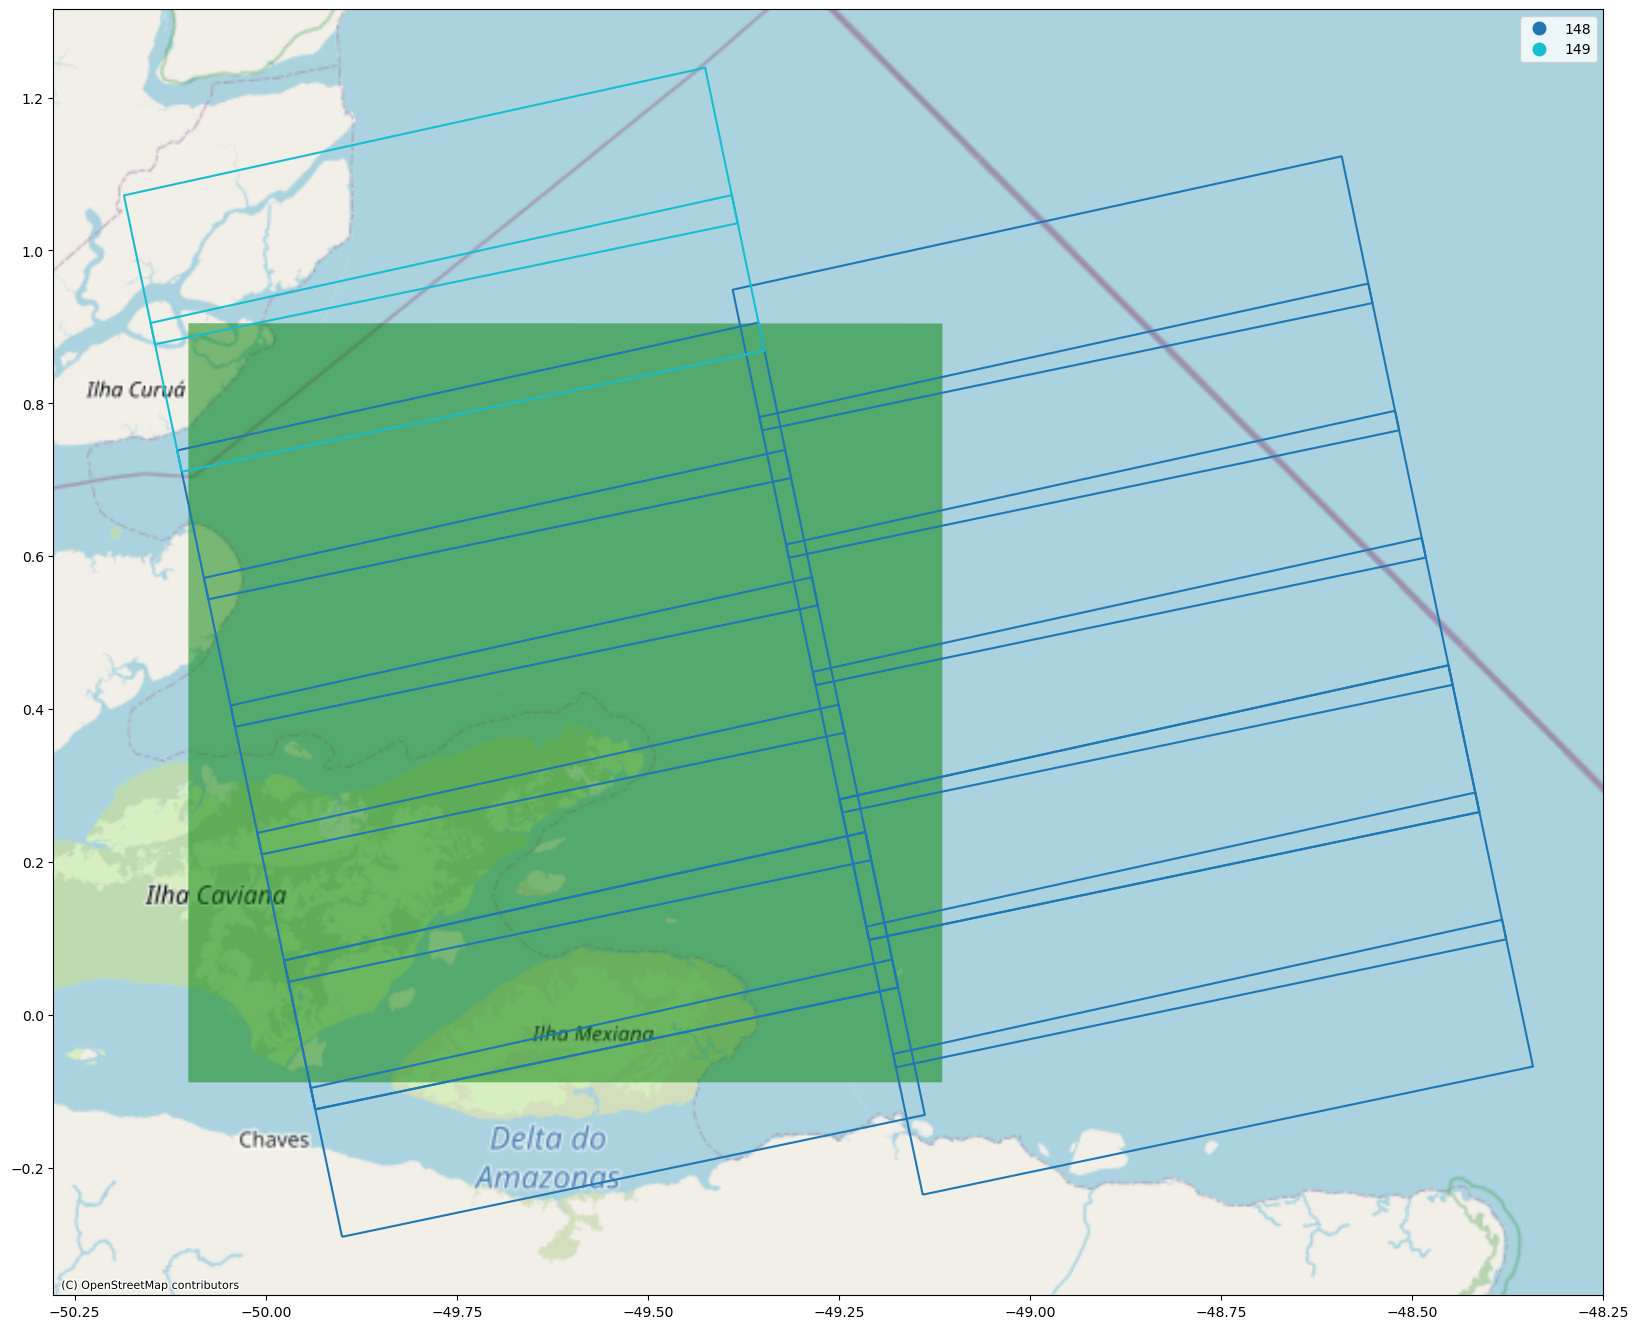

In [29]:
df_mrgs_burst_subset = df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == mgrs_tile_id_near_eq].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == mgrs_tile_id_near_eq].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))
df_burst_plot = df_burst_plot[df_burst_plot.track_number.isin([148, 149])]

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)

ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

# MGRS to Track Groups

In [30]:
def group_consecutive_tracks(tracks):
    tracks_sorted = sorted(tracks)
    groups = []
    current_group = [tracks_sorted[0]]

    for track in tracks_sorted[1:]:
        if track - current_group[-1] <= 1:
            current_group.append(track)
        else:
            if len(current_group) > 2:
                raise ValueError('Too many tracks; should be at most 2')
            groups.append(current_group)
            current_group = [track]
    if current_group:
        groups.append(current_group)
    return groups

group_consecutive_tracks([1, 4, 5, 10, 15, 20, 21, 23])

[[1], [4, 5], [10], [15], [20, 21], [23]]

In [31]:
%%time

df_mgrs2track = df_mgrs_burst.groupby('mgrs_tile_id')['track_number'].apply(lambda tracks: list(tracks.unique())).reset_index()
df_mgrs2track.head()

CPU times: user 501 ms, sys: 15.8 ms, total: 517 ms
Wall time: 511 ms


,mgrs_tile_id,track_number
0,01CCV,"[57, 130, 170, 24, 28]"
1,01DCA,"[170, 130, 24, 28, 101]"
2,01DCB,"[24, 101]"
3,01FBD,"[154, 131, 52, 58]"
4,01FBE,"[131, 154, 52, 58, 81]"


In [32]:
df_mgrs2track = pd.merge( df_mgrs[['mgrs_tile_id', 'geometry']], df_mgrs2track)
df_mgrs2track = df_mgrs2track.rename(columns={'track_number': 'track_numbers_all'})
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all
0,01CCV,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775...","[57, 130, 170, 24, 28]"
1,01DCA,"MULTIPOLYGON (((-179.50655 -71.18556, -179.639...","[170, 130, 24, 28, 101]"
2,01DCB,"MULTIPOLYGON (((-179.39691 -70.29009, -179.517...","[24, 101]"
3,01FBD,"MULTIPOLYGON (((-179.68350 -50.52082, -179.741...","[154, 131, 52, 58]"
4,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[131, 154, 52, 58, 81]"


In [33]:
df_bounds = df_mgrs2track.bounds
abs_lat = np.abs(df_bounds.miny.values, df_bounds.maxy.values)
df_mgrs2track['abs_lat'] = abs_lat

In [34]:
def track_grouping(row):
    track_numbers = row['track_numbers_all']
    abs_lat = row['abs_lat']
    if abs_lat < 70:
        track_groups = group_consecutive_tracks(track_numbers)
    else:
        track_groups = [[t] for t in sorted(track_numbers)]
    #track_group_strs = ['+'.join([str(s) for s in track_group]) for track_group in track_groups]
    #track_group_str = '_'.join(track_group_strs)
    return track_groups

df_mgrs2track['track_number_groups'] = df_mgrs2track.agg(track_grouping, axis=1)
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all,abs_lat,track_number_groups
0,01CCV,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775...","[57, 130, 170, 24, 28]",73.064633,"[[24], [28], [57], [130], [170]]"
1,01DCA,"MULTIPOLYGON (((-179.50655 -71.18556, -179.639...","[170, 130, 24, 28, 101]",72.168984,"[[24], [28], [101], [130], [170]]"
2,01DCB,"MULTIPOLYGON (((-179.39691 -70.29009, -179.517...","[24, 101]",71.273697,"[[24], [101]]"
3,01FBD,"MULTIPOLYGON (((-179.68350 -50.52082, -179.741...","[154, 131, 52, 58]",51.507088,"[[52], [58], [131], [154]]"
4,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[131, 154, 52, 58, 81]",50.608678,"[[52], [58], [81], [131], [154]]"


In [35]:
def group_idxs(groups:list) -> dict:
    out = {track: group_idx for group_idx, group in enumerate(groups) for track in group}
    return out
    
df_mgrs2track['track_number_group_idxs'] = df_mgrs2track.track_number_groups.map(group_idxs)
df_mgrs2track['n_track_groups'] = df_mgrs2track.track_number_groups.map(len)
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all,abs_lat,track_number_groups,track_number_group_idxs,n_track_groups
0,01CCV,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775...","[57, 130, 170, 24, 28]",73.064633,"[[24], [28], [57], [130], [170]]","{24: 0, 28: 1, 57: 2, 130: 3, 170: 4}",5
1,01DCA,"MULTIPOLYGON (((-179.50655 -71.18556, -179.639...","[170, 130, 24, 28, 101]",72.168984,"[[24], [28], [101], [130], [170]]","{24: 0, 28: 1, 101: 2, 130: 3, 170: 4}",5
2,01DCB,"MULTIPOLYGON (((-179.39691 -70.29009, -179.517...","[24, 101]",71.273697,"[[24], [101]]","{24: 0, 101: 1}",2
3,01FBD,"MULTIPOLYGON (((-179.68350 -50.52082, -179.741...","[154, 131, 52, 58]",51.507088,"[[52], [58], [131], [154]]","{52: 0, 58: 1, 131: 2, 154: 3}",4
4,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[131, 154, 52, 58, 81]",50.608678,"[[52], [58], [81], [131], [154]]","{52: 0, 58: 1, 81: 2, 131: 3, 154: 4}",5


In [36]:
df_mgrs2track.shape[0] == len(df_mgrs2track.mgrs_tile_id.unique())

True

In [37]:
mgrs2track_group = df_mgrs2track[['mgrs_tile_id', 'track_number_group_idxs']].set_index('mgrs_tile_id').to_dict()['track_number_group_idxs']
#mgrs2track_group

## Update The MGRS/Burst Table

In [38]:
df_mgrs_burst.head()

,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121820-IW1,DESCENDING,57
1,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121819-IW1,DESCENDING,57
2,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121818-IW1,DESCENDING,57
3,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121817-IW1,DESCENDING,57
4,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T130-278615-IW1,DESCENDING,130


In [39]:
%%time

def label_acquisition_group(row):
    mgrs_tile = row['mgrs_tile_id']
    track = row['track_number']
    track_group = mgrs2track_group[mgrs_tile][track]
    return track_group

df_mgrs_burst['acq_group_id_within_mgrs_tile'] = df_mgrs_burst.agg(label_acquisition_group, axis=1)
df_mgrs_burst.head()

CPU times: user 6.81 s, sys: 148 ms, total: 6.96 s
Wall time: 7.24 s


,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121820-IW1,DESCENDING,57,2
1,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121819-IW1,DESCENDING,57,2
2,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121818-IW1,DESCENDING,57,2
3,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T057-121817-IW1,DESCENDING,57,2
4,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775...",T130-278615-IW1,DESCENDING,130,3


In [40]:
df_mgrs_burst.shape

(1954929, 8)

# Counting The Number of Passes (i.e. Track Groups) Per MGRS Tile

Text(0, 0.5, 'Frequency')

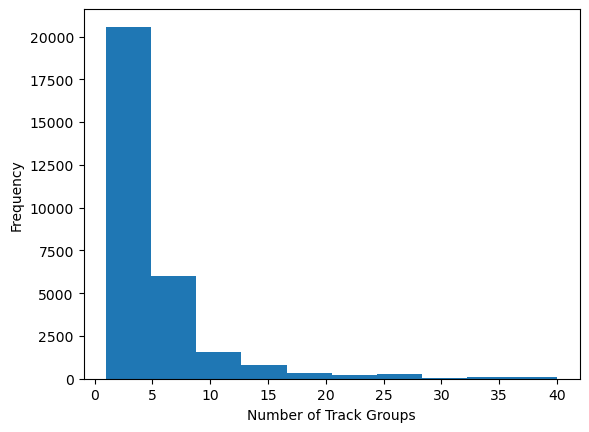

In [41]:
plt.hist(df_mgrs2track.n_track_groups.values)
plt.xlabel('Number of Track Groups')
plt.ylabel('Frequency')

# Calculating Area Per Pass in km${}^2$

In [42]:
df_burst_groups = pd.merge(df_burst_final, 
                           df_mgrs_burst[['jpl_burst_id', 'mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'geometry']], 
                           on='jpl_burst_id', 
                           how='left', 
                           suffixes=('', '_mgrs')
                          )

In [43]:
df_burst_groups.head()

,jpl_burst_id,orbit_pass,track_number,geometry,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry_mgrs
0,T001-000025-IW1,ASCENDING,1,"POLYGON ((2.53190 4.75701, 3.29631 4.91201, 3....",31NDF,0.0,"POLYGON ((2.09698 5.42755, 2.09832 4.43435, 3...."
1,T001-000025-IW1,ASCENDING,1,"POLYGON ((2.53190 4.75701, 3.29631 4.91201, 3....",31NEF,0.0,"POLYGON ((2.99982 5.42823, 2.99982 4.43490, 3...."
2,T001-000025-IW2,ASCENDING,1,"POLYGON ((3.25912 4.97460, 4.06055 5.13657, 4....",31NEF,0.0,"POLYGON ((2.99982 5.42823, 2.99982 4.43490, 3...."
3,T001-000025-IW2,ASCENDING,1,"POLYGON ((3.25912 4.97460, 4.06055 5.13657, 4....",31NFF,0.0,"POLYGON ((3.90266 5.42755, 3.90132 4.43435, 4...."
4,T001-000025-IW3,ASCENDING,1,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4....",31NEF,0.0,"POLYGON ((2.99982 5.42823, 2.99982 4.43490, 3...."


In [44]:
%%time

df_burst_groups_d = df_burst_groups.dissolve(by=['mgrs_tile_id', 'acq_group_id_within_mgrs_tile'], aggfunc='first').reset_index(drop=False)
df_burst_groups_d.head()

/Users/cmarshak/miniforge3/envs/dist-s1/lib/python3.12/site-packages/shapely/set_operations.py:419: RuntimeWarning: divide by zero encountered in unary_union
  return lib.unary_union(collections, **kwargs)


CPU times: user 59.9 s, sys: 566 ms, total: 1min
Wall time: 1min


,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry,jpl_burst_id,orbit_pass,track_number,geometry_mgrs
0,01CCV,0.0,"POLYGON ((176.12152 -72.45338, 177.98593 -71.8...",T024-051089-IW2,ASCENDING,24,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."
1,01CCV,1.0,"POLYGON ((177.49214 -72.02298, 175.62551 -71.5...",T028-059521-IW1,DESCENDING,28,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."
2,01CCV,2.0,"POLYGON ((178.16207 -73.18101, 178.12485 -73.1...",T057-121817-IW1,DESCENDING,57,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."
3,01CCV,3.0,"POLYGON ((177.12869 -72.85754, 177.12832 -72.8...",T130-278609-IW1,DESCENDING,130,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."
4,01CCV,4.0,"POLYGON ((175.86968 -72.48283, 177.40875 -71.9...",T170-364681-IW3,ASCENDING,170,"MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."


In [45]:
df_burst_groups_d = df_burst_groups_d[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'geometry', 'geometry_mgrs']]

<Axes: >

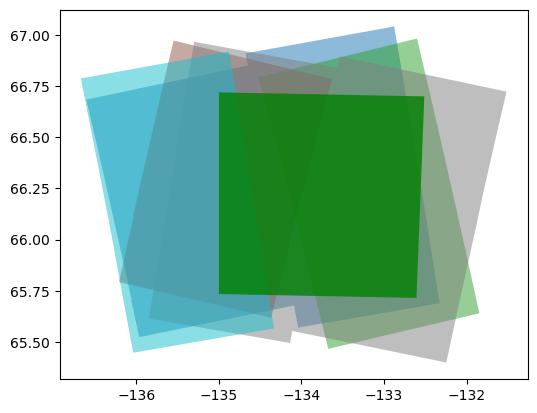

In [46]:
fig, ax = plt.subplots()

K = 10004
df_t = df_burst_groups_d.iloc[K:K + 5].reset_index()
df_t.plot(column='acq_group_id_within_mgrs_tile', categorical=True, ax=ax, alpha=.5)
df_mgrs[df_mgrs.mgrs_tile_id.isin(df_t.mgrs_tile_id.unique().tolist())].plot(ax=ax, alpha=.8, color='green')

In [47]:
geos_l = df_burst_groups_d.geometry.tolist()[:]
geos_r = df_burst_groups_d.geometry_mgrs.tolist()[:]

100%|█| 157865/157865 [00:06<00:00, 251


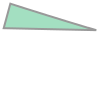

In [48]:
import shapely
from mpire import WorkerPool

with WorkerPool(n_jobs=5, use_dill=True) as pool:
        geos_intersected = pool.map(shapely.intersection, 
                                    zip(geos_l, geos_r),
                                    progress_bar=True, 
                                    progress_bar_style='std', 
                                    iterable_len=len(geos_l),
                                    concatenate_numpy_output=False)
geos_intersected[10]

In [49]:
df_burst_groups_area = gpd.GeoDataFrame(df_burst_groups_d[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile']],
                                        geometry=geos_intersected,
                                        crs=CRS.from_epsg(4326))
df_burst_groups_area.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry
0,01CCV,0.0,"POLYGON ((177.14766 -72.13813, 177.18934 -72.0..."
1,01CCV,1.0,"POLYGON ((177.49214 -72.02298, 177.14377 -72.1..."
2,01CCV,2.0,"POLYGON ((177.33209 -72.31042, 177.48763 -72.2..."
3,01CCV,3.0,"POLYGON ((177.12832 -72.85744, 176.88283 -72.9..."
4,01CCV,4.0,"POLYGON ((177.18378 -72.02923, 177.18934 -72.0..."


In [50]:
df_burst_groups_area['area_km2'] = df_burst_groups_area.to_crs('3395')['geometry'].map(lambda p: p.area / 10**6)
df_burst_groups_area.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry,area_km2
0,01CCV,0.0,"POLYGON ((177.14766 -72.13813, 177.18934 -72.0...",873.679413
1,01CCV,1.0,"POLYGON ((177.49214 -72.02298, 177.14377 -72.1...",869.655051
2,01CCV,2.0,"POLYGON ((177.33209 -72.31042, 177.48763 -72.2...",50218.711510
3,01CCV,3.0,"POLYGON ((177.12832 -72.85744, 176.88283 -72.9...",43961.833541
4,01CCV,4.0,"POLYGON ((177.18378 -72.02923, 177.18934 -72.0...",13.683410


In [51]:
df_mgrs_burst_with_area = pd.merge(df_mgrs_burst[[c for c in df_mgrs_burst.columns if 'area' not in c]], 
                                   df_burst_groups_area[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'area_km2']],
                                   how='left',
                                   on=['mgrs_tile_id', 'acq_group_id_within_mgrs_tile'])
assert df_mgrs_burst_with_area.shape[0] == df_mgrs_burst.shape[0]
df_mgrs_burst = df_mgrs_burst_with_area
df_mgrs_burst.rename(columns={'area_km2': 'area_per_acq_group_km2'}, inplace=True)
df_mgrs_burst_filtered = df_mgrs_burst.drop(columns=['epsg', 'utm_wkt', 'geometry'])
df_mgrs_burst_filtered.head()

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2
0,01CCV,T057-121820-IW1,DESCENDING,57,2,50218.711510
1,01CCV,T057-121819-IW1,DESCENDING,57,2,50218.711510
2,01CCV,T057-121818-IW1,DESCENDING,57,2,50218.711510
3,01CCV,T057-121817-IW1,DESCENDING,57,2,50218.711510
4,01CCV,T130-278615-IW1,DESCENDING,130,3,43961.833541


In [52]:
ind = (df_mgrs_burst.area_per_acq_group_km2.values < 100)
(ind).sum()

7004

# Append Burst Count Per MGRS Tile and Data-take

In [53]:
group = ['mgrs_tile_id', 'acq_group_id_within_mgrs_tile']
df_counts = df_mgrs_burst_filtered.groupby(group).size().reset_index(name='n_bursts_per_acq_group')
df_counts.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,n_bursts_per_acq_group
0,01CCV,0,1
1,01CCV,1,1
2,01CCV,2,5
3,01CCV,3,8
4,01CCV,4,1


In [54]:
df_mgrs_burst_filtered_with_counts = pd.merge(df_mgrs_burst_filtered, df_counts, how='left', on=group)
df_mgrs_burst_filtered_with_counts.head()

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2,n_bursts_per_acq_group
0,01CCV,T057-121820-IW1,DESCENDING,57,2,50218.711510,5
1,01CCV,T057-121819-IW1,DESCENDING,57,2,50218.711510,5
2,01CCV,T057-121818-IW1,DESCENDING,57,2,50218.711510,5
3,01CCV,T057-121817-IW1,DESCENDING,57,2,50218.711510,5
4,01CCV,T130-278615-IW1,DESCENDING,130,3,43961.833541,8


# Filtering by Area and number of bursts

In [55]:
ind_area = df_mgrs_burst_filtered_with_counts.area_per_acq_group_km2 > 100
ind_burst = df_mgrs_burst_filtered_with_counts.n_bursts_per_acq_group >= 3

df_mgrs_burst_final = df_mgrs_burst_filtered_with_counts[ind_area & ind_burst].reset_index(drop=True)
df_mgrs_burst_final.shape

(1939854, 7)

In [56]:
df_mgrs_burst_final.to_parquet('mgrs_burst_lookup_table.parquet', compression='zstd')

# Serializing Burst data

In [58]:
df_burst_final.shape

(587763, 4)

In [59]:
dist_s1_bursts = df_mgrs_burst_final.jpl_burst_id.unique().tolist()
df_burst_final_dist_s1 = df_burst_final[df_burst_final.jpl_burst_id.isin(dist_s1_bursts)][['jpl_burst_id', 'geometry']].reset_index(drop=True)
df_burst_final_dist_s1.shape

(587499, 2)

In [65]:
df_burst_final_dist_s1.to_parquet('jpl_burst_geo.parquet', compression='zstd')